In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('polynomial_regression_40rows.csv')

In [3]:
df.head()

,Feature1,Feature2,Target
0,0.000,3.729,40.840
1,1.282,1.215,4.274
2,2.564,1.881,50.911
3,3.846,1.737,30.402
4,5.128,1.704,26.632


In [4]:
df.isnull().sum()

Feature1    0
Feature2    0
Target      0
dtype: int64

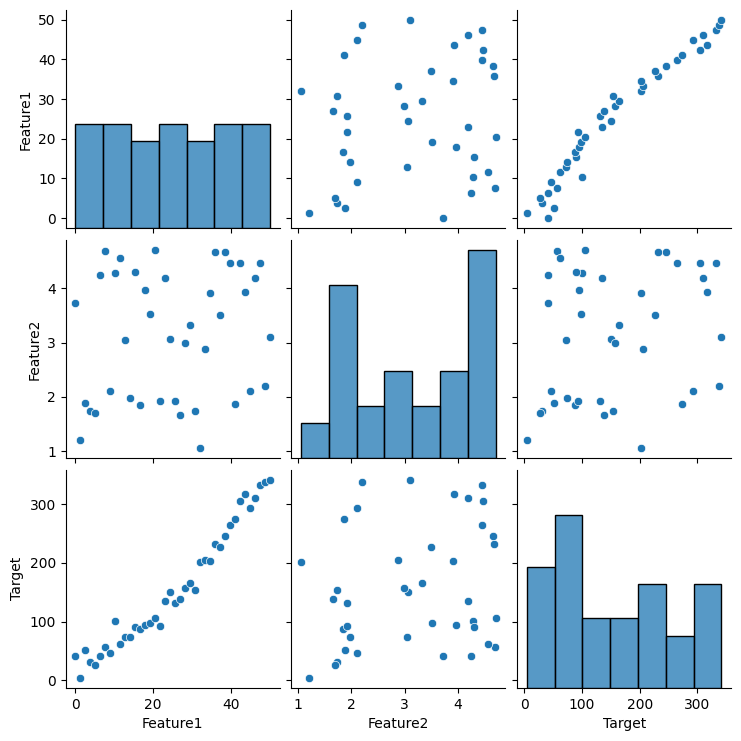

In [5]:
sns.pairplot(df)

In [7]:
df.corr()

,Feature1,Feature2,Target
Feature1,1.000000,0.169616,0.975553
Feature2,0.169616,1.000000,0.220706
Target,0.975553,0.220706,1.000000


In [8]:
##Seprate the iinput and output data
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [20]:
## Now do the Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=7)

In [21]:
## Now apply the liner regresion and check the accuracy
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)

In [22]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred=regression.predict(X_test)

In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

706.5449952243704
23.908001656155015
26.580914115665216


In [26]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.9492362847724599


In [27]:
## Now try with Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)

In [28]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [29]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred_poly=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred_poly)
score

0.9819794899737055

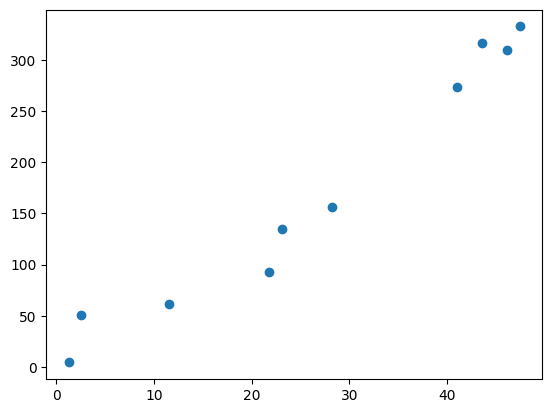

In [32]:
plt.scatter(X_test['Feature1'],y_test)

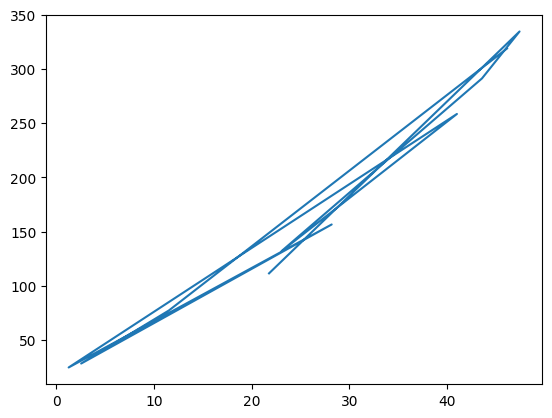

In [34]:
plt.plot(X_test['Feature1'],y_pred_poly)

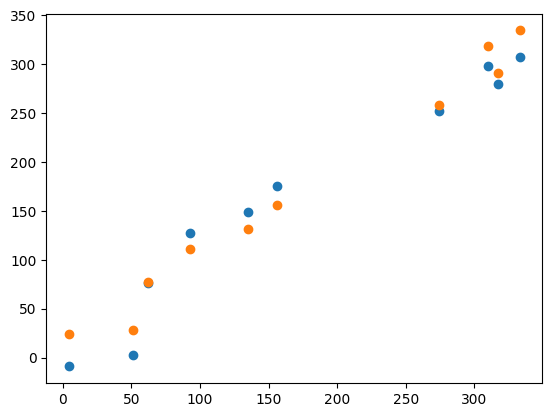

In [45]:

plt.scatter(y_test,y_pred)
plt.scatter(y_test,y_pred_poly)